# Experiment 3: CIFAR-10-C Distribution Shift Analysis

## Objective

This experiment evaluates the trained ResNet-18 baseline under distribution shifts using CIFAR-10-C, a benchmark containing corrupted versions of CIFAR-10 test images.

We will investigate how common image corruptions affect classification accuracy, predictive confidence, and model reliability.

## Research questions

1. How much does classification accuracy decrease under image corruption?
2. Does the model remain highly confident when its predictions become incorrect?
3. Do different corruption types affect the model differently?

## Method

We will load the same trained ResNet-18 checkpoint used in the baseline and feature-extraction experiments. The model will be evaluated on clean and corrupted images without additional training on the corrupted data.

The resulting predictions and confidence scores will provide the foundation for subsequent feature-displacement and calibration experiments.


In [4]:

import os

for root, dirs, files in os.walk("/kaggle/input"):
    for name in files:
        if name in [
            "gaussian_noise.npy",
            "motion_blur.npy",
            "labels.npy"
        ]:
            print(os.path.join(root, name))

/kaggle/input/datasets/harshadakhatu/cifar-10-c/CIFAR-10-C/motion_blur.npy
/kaggle/input/datasets/harshadakhatu/cifar-10-c/CIFAR-10-C/labels.npy
/kaggle/input/datasets/harshadakhatu/cifar-10-c/CIFAR-10-C/gaussian_noise.npy


In [5]:

import os

for root, dirs, files in os.walk("/kaggle/input"):
    if files:
        print(f"\nFolder: {root}")
        for name in sorted(files):
            print(" ", name)


Folder: /kaggle/input/datasets/harshadakhatu/cifar-10-c/CIFAR-10-C
  brightness.npy
  contrast.npy
  defocus_blur.npy
  elastic_transform.npy
  fog.npy
  frost.npy
  gaussian_blur.npy
  gaussian_noise.npy
  glass_blur.npy
  impulse_noise.npy
  jpeg_compression.npy
  labels.npy
  motion_blur.npy
  pixelate.npy
  saturate.npy
  shot_noise.npy
  snow.npy
  spatter.npy
  speckle_noise.npy
  zoom_blur.npy


In [6]:

import os
import numpy as np

data_dir = "/kaggle/input/datasets/harshadakhatu/cifar-10-c/CIFAR-10-C"

for filename in ["gaussian_noise.npy", "motion_blur.npy", "labels.npy"]:
    path = os.path.join(data_dir, filename)
    arr = np.load(path, mmap_mode="r")
    print(f"{filename}: shape={arr.shape}, dtype={arr.dtype}")
    del arr

gaussian_noise.npy: shape=(50000, 32, 32, 3), dtype=uint8
motion_blur.npy: shape=(50000, 32, 32, 3), dtype=uint8
labels.npy: shape=(50000,), dtype=uint8


In [7]:

import os
import numpy as np

data_dir = "/kaggle/input/datasets/harshadakhatu/cifar-10-c/CIFAR-10-C"

# Load only severity level 1
X_corrupt = np.load(
    os.path.join(data_dir, "gaussian_noise.npy"),
    mmap_mode="r"
)[:10000]

y_corrupt = np.load(
    os.path.join(data_dir, "labels.npy"),
    mmap_mode="r"
)[:10000]

print("Corruption: Gaussian noise")
print("Severity: 1")
print("Images shape:", X_corrupt.shape)
print("Labels shape:", y_corrupt.shape)
print("Image dtype:", X_corrupt.dtype)
print("Label dtype:", y_corrupt.dtype)
print("First 10 labels:", y_corrupt[:10])

Corruption: Gaussian noise
Severity: 1
Images shape: (10000, 32, 32, 3)
Labels shape: (10000,)
Image dtype: uint8
Label dtype: uint8
First 10 labels: [3 8 8 0 6 6 1 6 3 1]


In [8]:
checkpoint_path = "/kaggle/input/datasets/kimi11/checkpoint/baseline_resnet18_cifar10.pth"

In [11]:

import torch

checkpoint = torch.load(
    checkpoint_path,
    map_location="cpu",
    weights_only=True
)

print("Checkpoint type:", type(checkpoint))

if isinstance(checkpoint, dict):
    print("Checkpoint keys:", list(checkpoint.keys())[:20])

    if "state_dict" in checkpoint:
        weights = checkpoint["state_dict"]
    elif "model_state_dict" in checkpoint:
        weights = checkpoint["model_state_dict"]
    else:
        weights = checkpoint

    print("\nFirst parameter names and shapes:")
    for name, value in list(weights.items())[:12]:
        if hasattr(value, "shape"):
            print(name, tuple(value.shape))

Checkpoint type: <class 'collections.OrderedDict'>
Checkpoint keys: ['conv1.weight', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'bn1.num_batches_tracked', 'layer1.0.conv1.weight', 'layer1.0.bn1.weight', 'layer1.0.bn1.bias', 'layer1.0.bn1.running_mean', 'layer1.0.bn1.running_var', 'layer1.0.bn1.num_batches_tracked', 'layer1.0.conv2.weight', 'layer1.0.bn2.weight', 'layer1.0.bn2.bias', 'layer1.0.bn2.running_mean', 'layer1.0.bn2.running_var', 'layer1.0.bn2.num_batches_tracked', 'layer1.1.conv1.weight', 'layer1.1.bn1.weight']

First parameter names and shapes:
conv1.weight (64, 3, 3, 3)
bn1.weight (64,)
bn1.bias (64,)
bn1.running_mean (64,)
bn1.running_var (64,)
bn1.num_batches_tracked ()
layer1.0.conv1.weight (64, 64, 3, 3)
layer1.0.bn1.weight (64,)
layer1.0.bn1.bias (64,)
layer1.0.bn1.running_mean (64,)
layer1.0.bn1.running_var (64,)
layer1.0.bn1.num_batches_tracked ()


In [13]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=None)

# Match the CIFAR-10 architecture
model.conv1 = nn.Conv2d(
    3, 64, kernel_size=3, stride=1, padding=1, bias=False
)
model.maxpool = nn.Identity()

# CIFAR-10 has 10 output classes
model.fc = nn.Linear(model.fc.in_features, 10)

# Remove a possible DataParallel prefix
weights = {
    key.replace("module.", "", 1) if key.startswith("module.") else key: value
    for key, value in weights.items()
}

model.load_state_dict(weights)
model = model.to(device)
model.eval()

print("Checkpoint loaded successfully.")
print("Device:", device)

Checkpoint loaded successfully.
Device: cuda


Reconstructing means rebuilding the model's architecture in code so that your saved checkpoint can be loaded into it.

Think of your ResNet-18 as a machine:

Architecture: The machine's design — its layers, connections, and output structure.

Checkpoint (.pth file): The learned values stored inside the machine, called weights and biases.

Reconstruction: Recreating the same machine design so those learned values can be loaded back into it.

For your experiment:

We define the ResNet-18 architecture in Python.

We load the weights from baseline_resnet18_cifar10.pth.

The model uses those existing learned weights to classify corrupted images.

We measure how well it performs on Gaussian noise.

In [14]:
import os
import numpy as np

data_dir = "/kaggle/input/datasets/harshadakhatu/cifar-10-c/CIFAR-10-C"

X_corrupt = np.load(
    os.path.join(data_dir, "gaussian_noise.npy"),
    mmap_mode="r"
)[:10000]

y_corrupt = np.load(
    os.path.join(data_dir, "labels.npy"),
    mmap_mode="r"
)[:10000]

print("Corruption: Gaussian noise")
print("Severity: 1")
print("Images shape:", X_corrupt.shape)
print("Labels shape:", y_corrupt.shape)
print("Image data type:", X_corrupt.dtype)
print("Label data type:", y_corrupt.dtype)

Corruption: Gaussian noise
Severity: 1
Images shape: (10000, 32, 32, 3)
Labels shape: (10000,)
Image data type: uint8
Label data type: uint8


This cell runs the trained ResNet-18 on the 10,000 Gaussian-noise images and calculates its classification accuracy. It does not retrain the model.

In [15]:
import torch
import numpy as np

model.eval()

correct = 0
total = 0
batch_size = 128

with torch.no_grad():
    for start in range(0, len(X_corrupt), batch_size):
        end = min(start + batch_size, len(X_corrupt))

        # Convert images from NHWC to NCHW and scale pixels to [0, 1]
        images = np.array(X_corrupt[start:end], copy=True)
        images = torch.from_numpy(images).permute(0, 3, 1, 2)
        images = images.float() / 255.0

        labels = torch.tensor(
            np.array(y_corrupt[start:end], copy=True),
            dtype=torch.long
        )

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

gaussian_noise_accuracy = 100 * correct / total

print("Corruption: Gaussian noise")
print("Severity: 1")
print(f"Correct predictions: {correct}/{total}")
print(f"Accuracy: {gaussian_noise_accuracy:.2f}%")

Corruption: Gaussian noise
Severity: 1
Correct predictions: 7181/10000
Accuracy: 71.81%




| Metric                       | Accuracy               |
| ---------------------------- | ---------------------- |
| Clean CIFAR-10 test accuracy | 81.45%                 |
| Gaussian noise, severity 1   | 71.81%                 |
| Accuracy drop                | 9.64 percentage points |

Calculation: 81.45−71.81=9.64



In [16]:
X_corrupt = np.load(
    os.path.join(data_dir, "motion_blur.npy"),
    mmap_mode="r"
)[:10000]

y_corrupt = np.load(
    os.path.join(data_dir, "labels.npy"),
    mmap_mode="r"
)[:10000]

correct = 0
total = 0
batch_size = 128

model.eval()

with torch.no_grad():
    for start in range(0, len(X_corrupt), batch_size):
        end = min(start + batch_size, len(X_corrupt))

        images = np.array(X_corrupt[start:end], copy=True)
        images = torch.from_numpy(images).permute(0, 3, 1, 2).float() / 255.0
        labels = torch.tensor(
            np.array(y_corrupt[start:end], copy=True),
            dtype=torch.long
        )

        images = images.to(device)
        labels = labels.to(device)

        predictions = model(images).argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

motion_blur_accuracy = 100 * correct / total

print("Corruption: Motion blur")
print("Severity: 1")
print(f"Correct predictions: {correct}/{total}")
print(f"Accuracy: {motion_blur_accuracy:.2f}%")

Corruption: Motion blur
Severity: 1
Correct predictions: 7754/10000
Accuracy: 77.54%


Motion blur severity 1 accuracy is 77.54%.

### Updated results — Severity 1

| Evaluation     | Accuracy | Drop from clean baseline (81.45%) |
| -------------- | -------- | --------------------------------- |
| Clean CIFAR-10 | 81.45%   | —                                 |
| Gaussian noise | 71.81%   | 9.64 percentage points            |
| Motion blur    | 77.54%   | 3.91 percentage points            |

Observation: At severity 1, Gaussian noise affects the model more than motion blur in these results.


In [17]:
X_corrupt = np.load(
    os.path.join(data_dir, "brightness.npy"),
    mmap_mode="r"
)[:10000]

y_corrupt = np.load(
    os.path.join(data_dir, "labels.npy"),
    mmap_mode="r"
)[:10000]

correct = 0
total = 0
batch_size = 128

model.eval()

with torch.no_grad():
    for start in range(0, len(X_corrupt), batch_size):
        end = min(start + batch_size, len(X_corrupt))

        images = np.array(X_corrupt[start:end], copy=True)
        images = torch.from_numpy(images).permute(0, 3, 1, 2).float() / 255.0
        labels = torch.tensor(
            np.array(y_corrupt[start:end], copy=True),
            dtype=torch.long
        )

        images = images.to(device)
        labels = labels.to(device)

        predictions = model(images).argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

brightness_accuracy = 100 * correct / total

print("Corruption: Brightness")
print("Severity: 1")
print(f"Correct predictions: {correct}/{total}")
print(f"Accuracy: {brightness_accuracy:.2f}%")

Corruption: Brightness
Severity: 1
Correct predictions: 8163/10000
Accuracy: 81.63%


Brightness severity 1 accuracy is 81.63%, slightly higher than your clean test accuracy of 81.45%.

### Updated FDCC results — Severity 1

| Evaluation     | Accuracy | Change vs. clean        |
| -------------- | -------- | ----------------------- |
| Clean CIFAR-10 | 81.45%   | —                       |
| Gaussian noise | 71.81%   | −9.64 percentage points |
| Motion blur    | 77.54%   | −3.91 percentage points |
| Brightness     | 81.63%   | +0.18 percentage points |

Observation: The model handles brightness changes relatively well at severity 1. A small increase over clean accuracy can occur due to differences in individual test samples; it does not necessarily mean brightness improves the model overall.


In [19]:
X_corrupt = np.load(
    os.path.join(data_dir, "contrast.npy"),
    mmap_mode="r"
)[:10000]

y_corrupt = np.load(
    os.path.join(data_dir, "labels.npy"),
    mmap_mode="r"
)[:10000]

correct = 0
total = 0
batch_size = 128

model.eval()

with torch.no_grad():
    for start in range(0, len(X_corrupt), batch_size):
        end = min(start + batch_size, len(X_corrupt))

        images = np.array(X_corrupt[start:end], copy=True)
        images = torch.from_numpy(images).permute(0, 3, 1, 2).float() / 255.0
        labels = torch.tensor(
            np.array(y_corrupt[start:end], copy=True),
            dtype=torch.long
        )

        images = images.to(device)
        labels = labels.to(device)

        predictions = model(images).argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

contrast_accuracy = 100 * correct / total

print("Corruption: Contrast")
print("Severity: 1")
print(f"Correct predictions: {correct}/{total}")
print(f"Accuracy: {contrast_accuracy:.2f}%")

Corruption: Contrast
Severity: 1
Correct predictions: 7996/10000
Accuracy: 79.96%


In [20]:
X_corrupt = np.load(
    os.path.join(data_dir, "defocus_blur.npy"),
    mmap_mode="r"
)[:10000]

y_corrupt = np.load(
    os.path.join(data_dir, "labels.npy"),
    mmap_mode="r"
)[:10000]

correct = 0
total = 0
batch_size = 128

model.eval()

with torch.no_grad():
    for start in range(0, len(X_corrupt), batch_size):
        end = min(start + batch_size, len(X_corrupt))

        images = np.array(X_corrupt[start:end], copy=True)
        images = torch.from_numpy(images).permute(0, 3, 1, 2).float() / 255.0
        labels = torch.tensor(
            np.array(y_corrupt[start:end], copy=True),
            dtype=torch.long
        )

        images = images.to(device)
        labels = labels.to(device)

        predictions = model(images).argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

defocus_blur_accuracy = 100 * correct / total

print("Corruption: Defocus blur")
print("Severity: 1")
print(f"Correct predictions: {correct}/{total}")
print(f"Accuracy: {defocus_blur_accuracy:.2f}%")

Corruption: Defocus blur
Severity: 1
Correct predictions: 8190/10000
Accuracy: 81.90%


In [21]:
X_corrupt = np.load(
    os.path.join(data_dir, "fog.npy"),
    mmap_mode="r"
)[:10000]

y_corrupt = np.load(
    os.path.join(data_dir, "labels.npy"),
    mmap_mode="r"
)[:10000]

correct = 0
total = 0
batch_size = 128

model.eval()

with torch.no_grad():
    for start in range(0, len(X_corrupt), batch_size):
        end = min(start + batch_size, len(X_corrupt))

        images = np.array(X_corrupt[start:end], copy=True)
        images = torch.from_numpy(images).permute(0, 3, 1, 2).float() / 255.0
        labels = torch.tensor(
            np.array(y_corrupt[start:end], copy=True),
            dtype=torch.long
        )

        images = images.to(device)
        labels = labels.to(device)

        predictions = model(images).argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

fog_accuracy = 100 * correct / total

print("Corruption: Fog")
print("Severity: 1")
print(f"Correct predictions: {correct}/{total}")
print(f"Accuracy: {fog_accuracy:.2f}%")

Corruption: Fog
Severity: 1
Correct predictions: 8108/10000
Accuracy: 81.08%


In [22]:
X_corrupt = np.load(
    os.path.join(data_dir, "elastic_transform.npy"),
    mmap_mode="r"
)[:10000]

y_corrupt = np.load(
    os.path.join(data_dir, "labels.npy"),
    mmap_mode="r"
)[:10000]

correct = 0
total = 0
batch_size = 128

model.eval()

with torch.no_grad():
    for start in range(0, len(X_corrupt), batch_size):
        end = min(start + batch_size, len(X_corrupt))

        images = np.array(X_corrupt[start:end], copy=True)
        images = torch.from_numpy(images).permute(0, 3, 1, 2).float() / 255.0
        labels = torch.tensor(
            np.array(y_corrupt[start:end], copy=True),
            dtype=torch.long
        )

        images = images.to(device)
        labels = labels.to(device)

        predictions = model(images).argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

elastic_transform_accuracy = 100 * correct / total

print("Corruption: Elastic transform")
print("Severity: 1")
print(f"Correct predictions: {correct}/{total}")
print(f"Accuracy: {elastic_transform_accuracy:.2f}%")

Corruption: Elastic transform
Severity: 1
Correct predictions: 7588/10000
Accuracy: 75.88%


In [23]:
import os
import numpy as np
import pandas as pd
import torch

remaining_corruptions = [
    "frost",
    "gaussian_blur",
    "glass_blur",
    "impulse_noise",
    "jpeg_compression",
    "pixelate",
    "saturate",
    "shot_noise",
    "snow",
    "spatter",
    "speckle_noise",
    "zoom_blur",
]

y_corrupt = np.load(
    os.path.join(data_dir, "labels.npy"),
    mmap_mode="r"
)[:10000]

results = []
batch_size = 128
model.eval()

for corruption in remaining_corruptions:
    X_corrupt = np.load(
        os.path.join(data_dir, f"{corruption}.npy"),
        mmap_mode="r"
    )[:10000]

    correct = 0
    total = 0

    with torch.no_grad():
        for start in range(0, len(X_corrupt), batch_size):
            end = min(start + batch_size, len(X_corrupt))

            images = np.array(X_corrupt[start:end], copy=True)
            images = torch.from_numpy(images).permute(0, 3, 1, 2).float() / 255.0

            labels = torch.tensor(
                np.array(y_corrupt[start:end], copy=True),
                dtype=torch.long
            )

            images = images.to(device)
            labels = labels.to(device)

            predictions = model(images).argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    accuracy = 100 * correct / total

    results.append({
        "corruption": corruption,
        "severity": 1,
        "correct": correct,
        "total": total,
        "accuracy_percent": round(accuracy, 2)
    })

    print(f"{corruption}: {correct}/{total} | Accuracy: {accuracy:.2f}%")

results_df = pd.DataFrame(results)
results_df.to_csv("cifar10c_severity1_remaining.csv", index=False)

print("\nAll remaining corruption tests completed.")
display(results_df)
print("Saved to cifar10c_severity1_remaining.csv")

frost: 7722/10000 | Accuracy: 77.22%
gaussian_blur: 8188/10000 | Accuracy: 81.88%
glass_blur: 4522/10000 | Accuracy: 45.22%
impulse_noise: 7276/10000 | Accuracy: 72.76%
jpeg_compression: 7525/10000 | Accuracy: 75.25%
pixelate: 7810/10000 | Accuracy: 78.10%
saturate: 7754/10000 | Accuracy: 77.54%
shot_noise: 7628/10000 | Accuracy: 76.28%
snow: 7386/10000 | Accuracy: 73.86%
spatter: 7732/10000 | Accuracy: 77.32%
speckle_noise: 7689/10000 | Accuracy: 76.89%
zoom_blur: 7619/10000 | Accuracy: 76.19%

All remaining corruption tests completed.


,corruption,severity,correct,total,accuracy_percent
0,frost,1,7722,10000,77.22
1,gaussian_blur,1,8188,10000,81.88
2,glass_blur,1,4522,10000,45.22
3,impulse_noise,1,7276,10000,72.76
4,jpeg_compression,1,7525,10000,75.25
5,pixelate,1,7810,10000,78.10
6,saturate,1,7754,10000,77.54
7,shot_noise,1,7628,10000,76.28
8,snow,1,7386,10000,73.86
9,spatter,1,7732,10000,77.32


Saved to cifar10c_severity1_remaining.csv


In [24]:
import pandas as pd

# Results from the first seven corruption tests
earlier_results = [
    {"corruption": "gaussian_noise", "accuracy_percent": 71.81},
    {"corruption": "motion_blur", "accuracy_percent": 77.54},
    {"corruption": "brightness", "accuracy_percent": 81.63},
    {"corruption": "contrast", "accuracy_percent": 79.96},
    {"corruption": "defocus_blur", "accuracy_percent": 81.90},
    {"corruption": "fog", "accuracy_percent": 81.08},
    {"corruption": "elastic_transform", "accuracy_percent": 75.88},
]

# Results from the 12-test batch
batch_results = results_df[["corruption", "accuracy_percent"]].to_dict("records")

all_results = pd.DataFrame(earlier_results + batch_results)

all_results["drop_from_clean_pp"] = (
    81.45 - all_results["accuracy_percent"]
).round(2)

all_results = all_results.sort_values(
    "accuracy_percent", ascending=True
).reset_index(drop=True)

print("Number of corruption types:", len(all_results))
print(f"Mean corruption accuracy: {all_results['accuracy_percent'].mean():.2f}%")
print(f"Clean test accuracy: 81.45%")
print(
    f"Mean accuracy drop: "
    f"{81.45 - all_results['accuracy_percent'].mean():.2f} percentage points"
)

display(all_results)

all_results.to_csv("cifar10c_all_corruptions_severity1.csv", index=False)
print("Saved: cifar10c_all_corruptions_severity1.csv")

Number of corruption types: 19
Mean corruption accuracy: 75.70%
Clean test accuracy: 81.45%
Mean accuracy drop: 5.75 percentage points


,corruption,accuracy_percent,drop_from_clean_pp
0,glass_blur,45.22,36.23
1,gaussian_noise,71.81,9.64
2,impulse_noise,72.76,8.69
3,snow,73.86,7.59
4,jpeg_compression,75.25,6.20
5,elastic_transform,75.88,5.57
6,zoom_blur,76.19,5.26
7,shot_noise,76.28,5.17
8,speckle_noise,76.89,4.56
9,frost,77.22,4.23


Saved: cifar10c_all_corruptions_severity1.csv


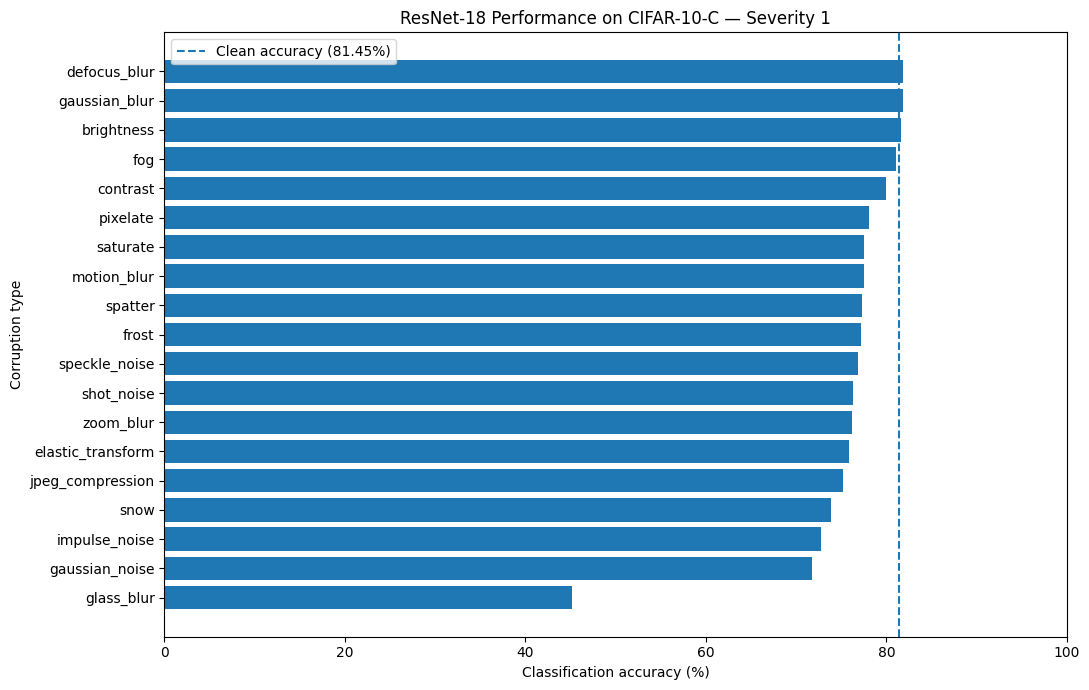

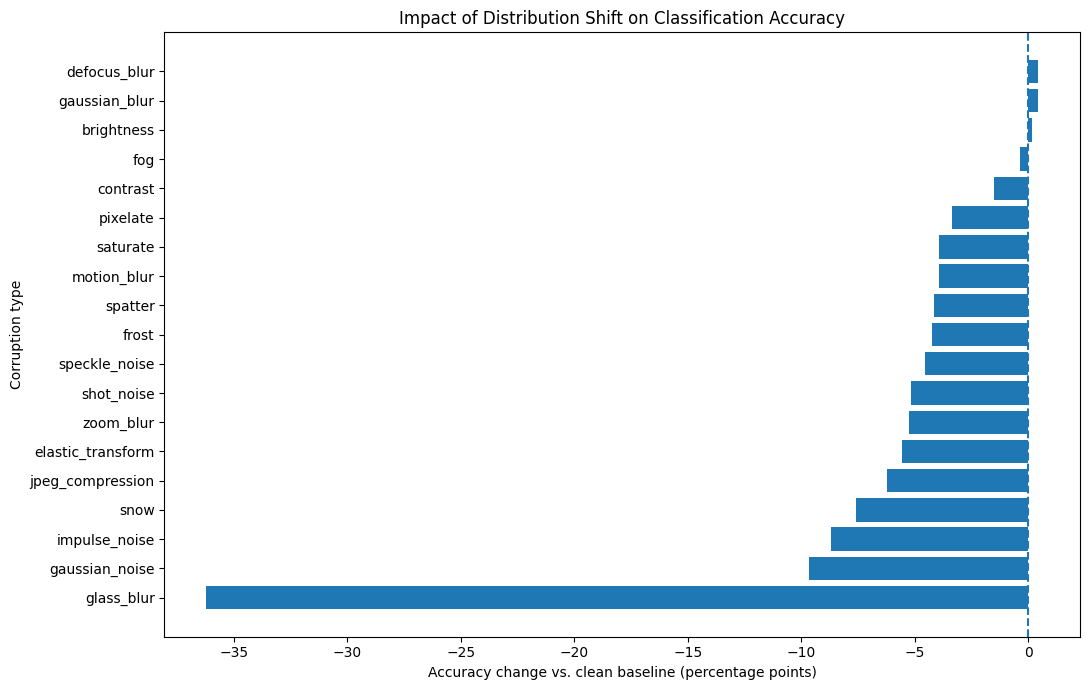

Download Chart 1:


/kaggle/working/cifar10c_accuracy_by_corruption.png

Download Chart 2:


/kaggle/working/cifar10c_accuracy_change.png

In [25]:

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, FileLink

CLEAN_ACCURACY = 81.45

# Sort from lowest to highest accuracy
plot_df = all_results.sort_values(
    "accuracy_percent", ascending=True
).copy()

# Chart 1: Accuracy by corruption type
plt.figure(figsize=(11, 7))

plt.barh(
    plot_df["corruption"],
    plot_df["accuracy_percent"]
)

plt.axvline(
    CLEAN_ACCURACY,
    linestyle="--",
    label="Clean accuracy (81.45%)"
)

plt.xlabel("Classification accuracy (%)")
plt.ylabel("Corruption type")
plt.title("ResNet-18 Performance on CIFAR-10-C — Severity 1")
plt.xlim(0, 100)
plt.legend()
plt.tight_layout()
plt.savefig("cifar10c_accuracy_by_corruption.png", dpi=300)
plt.show()

# Chart 2: Accuracy change relative to clean baseline
drop_df = plot_df.copy()
drop_df["accuracy_change"] = (
    drop_df["accuracy_percent"] - CLEAN_ACCURACY
)

plt.figure(figsize=(11, 7))

plt.barh(
    drop_df["corruption"],
    drop_df["accuracy_change"]
)

plt.axvline(0, linestyle="--")
plt.xlabel("Accuracy change vs. clean baseline (percentage points)")
plt.ylabel("Corruption type")
plt.title("Impact of Distribution Shift on Classification Accuracy")
plt.tight_layout()
plt.savefig("cifar10c_accuracy_change.png", dpi=300)
plt.show()

# Download links
print("Download Chart 1:")
display(FileLink("cifar10c_accuracy_by_corruption.png"))

print("Download Chart 2:")
display(FileLink("cifar10c_accuracy_change.png"))

In [26]:
import os
import numpy as np
import torch
import torch.nn.functional as F

data_dir = "/kaggle/input/datasets/harshadakhatu/cifar-10-c/CIFAR-10-C"

X = np.load(
    os.path.join(data_dir, "gaussian_noise.npy"),
    mmap_mode="r"
)[:10000]

y = np.load(
    os.path.join(data_dir, "labels.npy"),
    mmap_mode="r"
)[:10000]

all_confidences = []
all_correct = []

model.eval()

with torch.no_grad():
    for start in range(0, len(X), 128):
        end = min(start + 128, len(X))

        images = np.array(X[start:end], copy=True)
        images = torch.from_numpy(images).permute(0, 3, 1, 2).float() / 255.0
        labels = torch.tensor(
            np.array(y[start:end], copy=True),
            dtype=torch.long
        )

        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        probabilities = F.softmax(logits, dim=1)

        confidences, predictions = probabilities.max(dim=1)
        correct = predictions.eq(labels)

        all_confidences.extend(confidences.cpu().numpy())
        all_correct.extend(correct.cpu().numpy())

all_confidences = np.array(all_confidences)
all_correct = np.array(all_correct)

print("Images evaluated:", len(all_confidences))
print(f"Accuracy: {100 * all_correct.mean():.2f}%")
print(f"Mean confidence: {100 * all_confidences.mean():.2f}%")

Images evaluated: 10000
Accuracy: 71.81%
Mean confidence: 84.96%


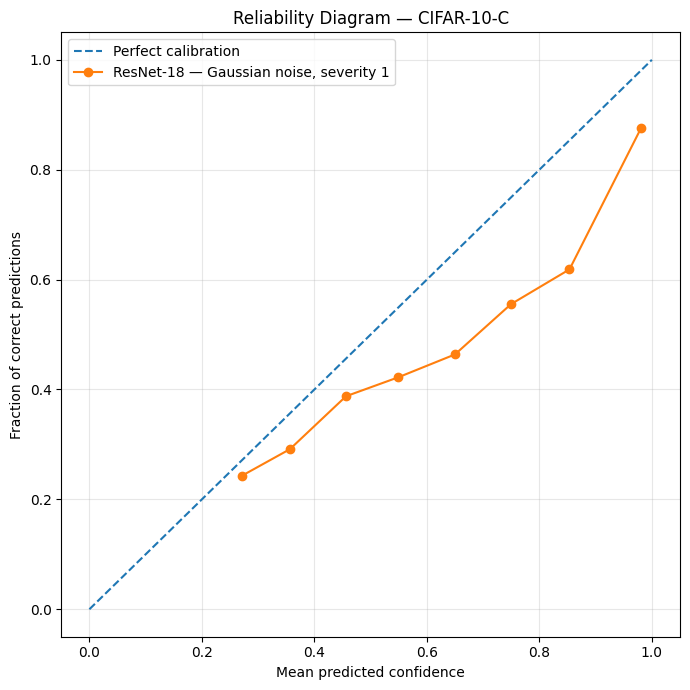

In [27]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

fraction_correct, mean_confidence = calibration_curve(
    all_correct.astype(int),
    all_confidences,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(7, 7))

plt.plot(
    [0, 1], [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.plot(
    mean_confidence,
    fraction_correct,
    marker="o",
    label="ResNet-18 — Gaussian noise, severity 1"
)

plt.xlabel("Mean predicted confidence")
plt.ylabel("Fraction of correct predictions")
plt.title("Reliability Diagram — CIFAR-10-C")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fdcc_reliability_gaussian_noise.png", dpi=300)
plt.show()

In [28]:
from IPython.display import FileLink, display
display(FileLink("fdcc_reliability_gaussian_noise.png"))

/kaggle/working/fdcc_reliability_gaussian_noise.png